In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

(0.8603000000000001, 0.9369428571428572)

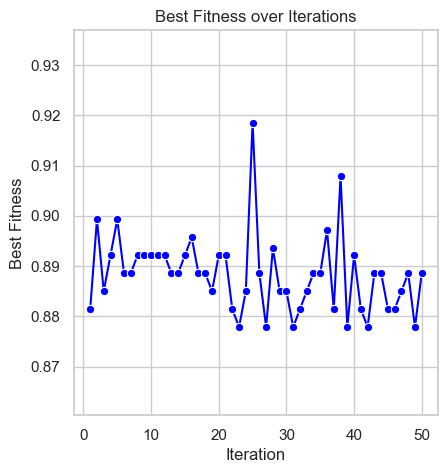

In [5]:
# Set seaborn style
sns.set(style="whitegrid")

# Step 1: Read the text file
# Change filename to run for different outputs
with open("pso_output.txt", "r") as file:
    raw_text = file.read()

# Step 2: Extract data using regex
pattern = r"Iteration - (\d+).*?Fitness: ([\d.]+).*?Number of Features: (\d+)"
matches = re.findall(pattern, raw_text, re.DOTALL)

# Step 3: Convert to DataFrame
df = pd.DataFrame(matches, columns=["Iteration", "Best Fitness", "Best Features"])
df["Iteration"] = df["Iteration"].astype(int)
df["Best Fitness"] = df["Best Fitness"].astype(float)
df["Best Features"] = df["Best Features"].astype(int)

# Optional: Compute % feature reduction assuming full = 28 features
TOTAL_FEATURES = 28
df["Reduction (%)"] = 100 * (1 - df["Best Features"] / TOTAL_FEATURES)

# Step 4: Plotting
plt.figure(figsize=(16, 5))

# Plot 1: Best Fitness
plt.subplot(1, 3, 1)
sns.lineplot(x="Iteration", y="Best Fitness", data=df, marker="o", color="blue")
plt.title("Best Fitness over Iterations")
plt.ylim(df["Best Fitness"].min() * 0.98, df["Best Fitness"].max() * 1.02)

Text(0.5, 1.0, 'Selected Features over Iterations')

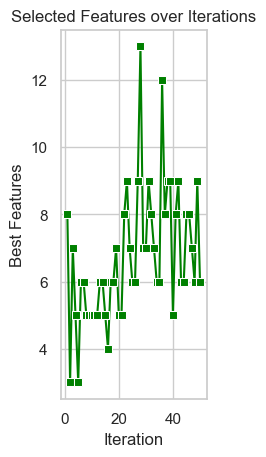

In [6]:
# Plot 2: Number of Features
plt.subplot(1, 3, 2)
sns.lineplot(x="Iteration", y="Best Features", data=df, marker="s", color="green")
plt.title("Selected Features over Iterations")


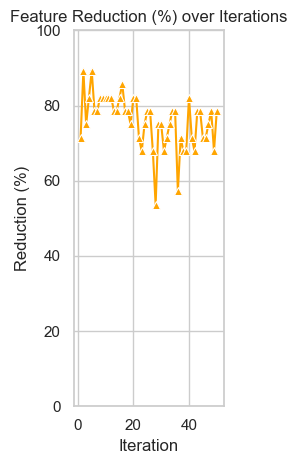

In [7]:
# Plot 3: Reduction Percentage
plt.subplot(1, 3, 3)
sns.lineplot(x="Iteration", y="Reduction (%)", data=df, marker="^", color="orange")
plt.title("Feature Reduction (%) over Iterations")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()